# Анализ результатов моделирования 

## Общие сведения

Как видно из раздела **Моделирование параметров прибытия подразделений пожарной охраны**, пользователь может самостоятельно проанализировать результаты моделирования. Однако, для дальнейшего конструирования алгоритмов решения задач определения дислокации подразделений пожарной охраны требуются предопределенные функции. В роли таких функций выступают класс-функции метрик.

```{mermaid}
flowchart LR

  model("**МОДЕЛИРОВАНИЕ
          ПАРАМЕТРОВ
          ПРИБЫТИЯ**")
  
  result["**РЕЗУЛЬТАТЫ**"]

  analyze("**АНАЛИЗ**
        ---
        Время прибытия
        ---
        Индекс прикрытия
        ---
        Границы районов выезда
        ---
        Зоны прикрытия")

  metrics[**МЕТРИКИ**]
        
  model -.-> result
  metrics --> analyze
  result --> analyze

```

В **Генезис** реализованы следующие метрики:
- Применительно к узлам ГДС (в практических расчетах интереса преимущественно не представляют, поэтому более подробно рассматриваются в разделе **Для разработчиков**):
  - `genesis.metrics.ArrivalTime`: метрики времени прибытия
  - `genesis.metrics.CoverIndex`: метрики индекса прикрытия
- Применительно к зданиям:
  - `fire_units.metrics.ArrivalTimeBuilding`: метрики времени прибытия
  - `fire_units.metrics.CoverIndexBuilding`: метрики индекса прикрытия
  - `fire_units.metrics.CoverIndexValue`: метрики взвешенного индекса прикрытия

## Метрики

Загрузка основных библиотек

In [1]:
import numpy as np
import osmnx as ox
import pandas as pd
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

import genesis as genesis


# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\nContextily', ctx.__version__,
      '\ngenesis:', genesis.__version__,
      )

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
Contextily 1.6.2 
genesis: 0.1.035


Расчет тестовых результатов моделирования (состояния)

In [3]:
from genesis.states import FirstArrivalUnitState
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


# 1. Загрузка исходных данных

## Загрузка ГДС
G = ox.load_graphml('data/kemerovo/gds.ml')

## Установка скоростного режима
set_graph_travel_times(
    G,
    speeds=DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)

## Упрощение графа (уменьшение количества узлов)
G = ox.simplification.simplify_graph(G)

## Загрузка пожарных подразделений
units = gpd.read_file('data/kemerovo/fire_units.gpkg')
### Сопоставление пожарных подразделений с ближайшими узлами ГДС
units['node'] = ox.distance.nearest_nodes(G, units.geometry.x, units.geometry.y)
### Формирование словаря подразделений для передачи алгоритму
units_dict = {k:v for k,v in zip(units['node'], units['name'])}

## Загрузка зданий
buildings = gpd.read_file('data/kemerovo/buildings.gpkg')
### Сопоставление зданий с ближайшими узлами ГДС
### Для полигональных объектов следует использовать центроиды: `geometry.centroid`
### !!! Здесь реализовано сопоставление для перепроецированных набора зданий и ГДС
### !!! во избежания появления предупреждений
centroids = ox.projection.project_gdf(buildings).geometry.centroid
buildings['node'] = ox.distance.nearest_nodes(ox.project_graph(G), 
                                              centroids.x,
                                              centroids.y
                                              )

## Загрузка границ населенного пункта
borders = gpd.read_file('data/kemerovo/borders.gpkg')
## Получение маски узлов графа (потенциальных мест возникновения пожара)
g_nodes = ox.graph_to_gdfs(G, edges=False)
nodes_mask = g_nodes.within(borders.union_all())



# 2. Сборка решения
## Выбор алгоритма моделирования 
## (алгоритмы расчета расчета кратчайшего пути
## и времени следования установлены по умолчанию)
state = FirstArrivalUnitState()


# 3. Моделирование параметров прибытия
times, nearest = state(env=G, points=units_dict, area=nodes_mask)

### Метрики времени прибытия {.unnumbered}

Для оценки времени прибытия к зданиям используется функция `fire_units.metrics.ArrivalTimeBuilding`.

In [4]:
from fire_units.metrics import ArrivalTimeBuilding


# Расчет среднего времени прибытия ко всем зданиям (по умолчанию)
## Настройка метрики
metric_function = ArrivalTimeBuilding(buildings)
## Вычисление метрики
result = metric_function(times)
# Округление
result = round(result, 1)
print('Среднее время прибытия:     ', result, 'мин')

# Расчет максимального времени прибытия ко всем зданиям
## Настройка метрики
metric_function = ArrivalTimeBuilding(buildings, f = np.max)
## Вычисление метрики
result = metric_function(times)
# Округление
result = round(result, 1)
print('Максимальное время прибытия:', result, 'мин')

# Расчет медианного времени прибытия ко всем зданиям
## Настройка метрики
metric_function = ArrivalTimeBuilding(buildings, f = np.median)
## Вычисление метрики
result = metric_function(times)
# Округление
result = round(result, 1)
print('Медиана времени прибытия:   ', result, 'мин')

# Расчет стандартного отклонения времени прибытия ко всем зданиям
## Настройка метрики
metric_function = ArrivalTimeBuilding(buildings, f = np.std)
## Вычисление метрики
result = metric_function(times)
# Округление
result = round(result, 1)
print('Ст.откл. времени прибытия:  ', result, 'мин')

Среднее время прибытия:      9.1 мин
Максимальное время прибытия: 28.4 мин
Медиана времени прибытия:    7.4 мин
Ст.откл. времени прибытия:   5.4 мин


### Метрики индекса прикрытия {.unnumbered}

Для оценки индекса прикрытия зданий используется функция `fire_units.metrics.CoverIndexBuilding`.

In [5]:
from fire_units.metrics import CoverIndexBuilding


# Расчет индекса прикрытия для 10 минутной зоны (ИП-10, по умолчанию)
## Настройка метрики
metric_function = CoverIndexBuilding(buildings)
## Вычисление метрики
result = metric_function(times)
# Округление
result = round(result, 1)
print('ИП-10: ', result, '%')

# Расчет индекса прикрытия для 20 минутной зоны (ИП-20)
## Настройка метрики
metric_function = CoverIndexBuilding(buildings, ip_val=20)
## Вычисление метрики
result = metric_function(times)
# Округление
result = round(result, 1)
print('ИП-20: ', result, '%')

ИП-10:  72.5 %
ИП-20:  93.6 %


### Метрика взвешенного индекса прикрытия {.unnumbered}

Для оценки взвешенного индекса прикрытия используется функция `fire_units.metrics.CoverIndexValue`.

Данная метрика подходит для определения индекса прикрытия не самих объектов, а некоторого их атрибутивного значения. В роли последнего может выступать, например, количество жильцов, этажность, значимость объекта или любые пользовательские значения.

Данную метрику рекомендуется применять для оценки прикрытия населенных пунктов при расчете расчете потребности в ПСЧ крупных территориальных образований (муниципальные образования, субъекты Федерации и т.д.)

In [ ]:
from genesis.metrics import CoverIndexValue

# В качестве веса будем использовать площадь зданий:
buildings['area'] = ox.projection.project_gdf(buildings).area


# Расчет взвешенного индекса прикрытия для 10 минутной зоны (ИП-10, по умолчанию)
## Настройка метрики
metric_function = CoverIndexValue(buildings, value_field='area')
## Вычисление метрики
result = metric_function(times)
# Округление
result = round(result, 1)
print('ИП-10 (по площади): ', result, '%')

# Расчет взвешенного индекса прикрытия для 20 минутной зоны (ИП-20, по умолчанию)
## Настройка метрики
metric_function = CoverIndexValue(buildings, value_field='area', ip_val=20)
## Вычисление метрики
result = metric_function(times)
# Округление
result = round(result, 1)
print('ИП-20 (по площади): ', result, '%')

ИП-10 (по площади):  78.6 %
ИП-20 (по площади):  96.9 %


:::{.callout-important}

### Важно

Моделирование состояния прибытия пожарных подразделений с использованием `genesis.states.FirstArrivalUnitState` и `genesis.states.ArrivalTimeMatrixState` имеет существенные различия связанные с особенностями расчета, поэтому результаты анализа, полученные с их помощью могут незначительно отличаться.

:::

## Анализ областей прикрытых подразделениями

Анализ выполняется путем построения карты на которой можно увидеть области в которые подразделения прибывают за нормативное время и в которые не успевают.

Также полезно увидеть области обслуживания каждой ПСЧ.

Результатов моделирования: 16792
Количество зданий: 37468


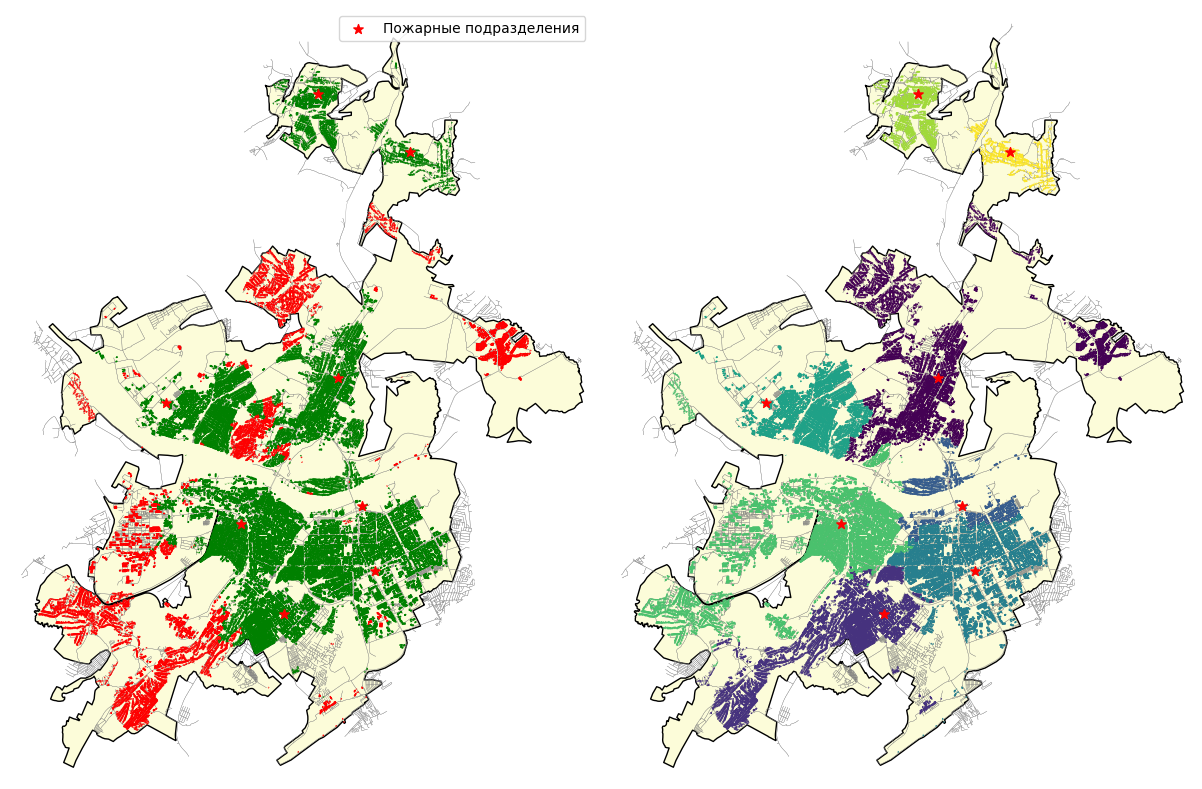

In [7]:
# Дополнение данных о зданиях данными результатами моделирования (по полю `node`)
buildings_s = buildings.copy()
buildings_s = buildings_s.merge(times, left_on='node', right_index=True)
buildings_s = buildings_s.merge(nearest, left_on='node', right_index=True)


# Определение цветов зданий (требуется для лучшей читаемости при печати полигонов):
clrs = {k:v for k,v in zip(units['name'], ox.plot.get_colors(n=len(units)))}
bld_clrs = [clrs[n] for n in buildings_s['nearest']]


# Подготовка холста для 2 карт
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,8), tight_layout=True)

# Карта 10 минутной зоны
borders.plot(ax=ax1, color='#fcfcd9', edgecolor='black')
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax1, close=False, show=False)
buildings_s[buildings_s['times']<=10].plot(ax=ax1, color='g', edgecolor='g') 
buildings_s[buildings_s['times']>10].plot(ax=ax1, color='r', edgecolor='r')
units.plot(ax=ax1, color='red', markersize=50, marker='*', label='Пожарные подразделения')
ax1.legend()

# Карта зон обслуживания
borders.plot(ax=ax2, color='#fcfcd9', edgecolor='black')
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax2, close=False, show=False)
buildings_s.plot(ax=ax2, facecolor=bld_clrs, edgecolor=bld_clrs)
units.plot(ax=ax2, color='red', markersize=50, marker='*', label='Пожарные подразделения')

plt.show()

## Анализ областей пересечения зон рекомендуемого размещения ПСЧ (по СП 11.13130.2009)

Для анализа требуется матрица прибытия, получаемая с использованием функции `genesis.states.get_atm`. Более подробно см. **Моделирование параметров прибытия подразделений пожарной охраны**.

In [ ]:
from genesis.states import get_atm

matrix = get_atm(G, 
                 data             = buildings,
                 data_sample_size = 1000,       # Размер выборки (чем меньше, тем быстрее расчет, но ниже точность)
                 cutoff           = 10,         # Допустимое время прибытия
                 )
print('Размер матрицы:', matrix.shape)

|########################################| 100.0%
Размер матрицы: (901, 17766)


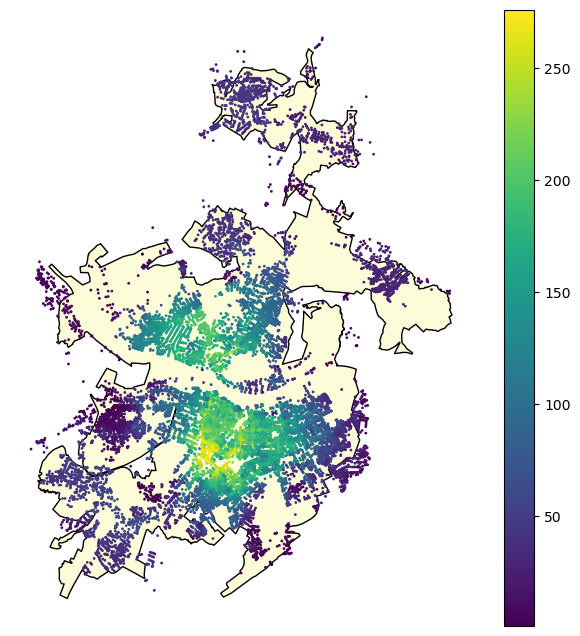

In [32]:
# Подсчитываем количество пространственных зон размещения пожарных депо
# пересекающихся в каждом из узлов ГДС
areas_count = (matrix<=10).sum(axis=0)

# Сопоставление узлов ГДС с количеством пересечений пространственных зон размещения пожарных депо
g_nodes = ox.graph_to_gdfs(G, edges=False)
g_nodes['areas_count'] = areas_count

# Печать карты с количеством пространственных зон размещения пожарных депо
fig, ax = plt.subplots(1, 1, figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.plot(ax=ax, column='areas_count', cmap='viridis', markersize=1, legend=True)
ax.set_axis_off()
plt.show()

## Определение границ районов выезда

Для большинства пользователей более удобным представляется использование для определения оптимальных границ районов выезда встроенных инструментов приложения QGIS. Расчет границ районов выезда с использованием Python приводится в разделе **Для разработчиков**.

Шаг 1. Сохранение результатов моделирования как GeoPackage

In [ ]:
# Дополнение данных о зданиях данными результатами моделирования (по полю `node`)
buildings = buildings.merge(nearest, left_on='node', right_index=True)

# Замена полигональной геометрии на центроиды с перепроецированием в локальную СК
buildings.geometry = ox.projection.project_gdf(buildings).centroid

# Сохранение результатов моделирования
buildings[['nearest', 'geometry']].to_file('data/kemerovo/buildings.gpkg', layer='nearest')

Шаг 2. Добавление слоя с результатами моделирования на карту QGIS

![](imgs/borders_0.png)

Шаг 3. Построение ячеек Вороного

:::{.callout-note}

#### Ячейки Вороного

Такой способ разделения пространства при котором оно будет разбито на ячейки, каждая точка которой будет относиться к ближайшей к ней точке.

:::

![Пункт меню](imgs/borders_1.png){#fig-borders-menu}

![Настройка](imgs/borders_2.png){#fig-borders-algset}

Рекомендуется указывать **Область буфера** более 0%, исходя из границ населенного пункта.

![Ячейки вороного](imgs/borders_3.png){#fig-borders-voronoi}

Шаг 4. Объединение ячеек вороного по признаку ближайшего подразделения

![Пункт меню Объединение по признаку](imgs/borders_4.png){#fig-voronoi-menu}

![Настройки алгоритма Объединения по признаку](imgs/borders_5.png){#fig-voronoi-algset}

В настройках алгоритма необходимо указать поле `nearest`, как признак объединения.

![Объединенные ячейки - видно, что они выходят за границы населенного пункта](imgs/borders_6.png){#fig-voronoi-result}

Шаг 5. Обрезка полученных полигонов по границе населенного пункта.

![Пункт меню Обрезка](imgs/borders_7.png){#fig-cut-menu}

![Настройка алгоритма обрезки](imgs/borders_8.png){#fig-cut-algset}

:::{.callout-important}

### Важно

СК исходного слоя и слоя наложения должны совпадать!

:::

![Результат обрезки по границам населенного пункта](imgs/borders_9.png){#fig-cut-result}